In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from scipy import stats

MAX_FUTURES_LAG = 4
MAX_RESIDUAL_ACF_LAG = 36
NORMALITY_ALPHA = 0.05

data = pd.read_csv("ex14.dat", sep=r"\s+")
# COLUMNS:
# "lnfuture": "log future price",
# "lnspot": "log spot price",
# "cost": "pct carry cost" (i.e. multiplied by 100)
data["futures_rets"] = data["lnfuture"].diff()
data["spot_rets"] = data["lnspot"].diff()
df = data[["futures_rets", "spot_rets", "cost"]].copy()
df["cost"] /= 100
df = df.dropna()
print(df)

      futures_rets  spot_rets     cost
1          0.00022    0.00005 -0.00165
2          0.00069    0.00007 -0.00165
3         -0.00023    0.00000 -0.00165
4          0.00000   -0.00007 -0.00165
5         -0.00011    0.00002 -0.00165
...            ...        ...      ...
7056       0.00023    0.00014  0.00000
7057       0.00011    0.00015  0.00000
7058       0.00011   -0.00007  0.00000
7059      -0.00022   -0.00011  0.00000
7060      -0.00023    0.00003  0.00000

[7060 rows x 3 columns]



Linear regression metrics
                         max_futures_lag  n_observations  n_predictors  r_squared  adj_r_squared            aic            bic  f_pvalue  residual_mean  \
model                                                                                                                                                     
spot ~ futures                         0            7060             1   0.150922       0.150801 -101373.852134 -101360.127733       0.0            0.0   
spot ~ futures lags 0-1                1            7059             2   0.167719       0.167483 -101497.597929 -101477.011753       0.0           -0.0   
spot ~ futures lags 0-2                2            7058             3   0.207008       0.206671 -101821.635454 -101794.187786       0.0           -0.0   
spot ~ futures lags 0-3                3            7057             4   0.238408       0.237976 -102089.321313 -102055.012436       0.0           -0.0   
spot ~ futures lags 0-4                4   

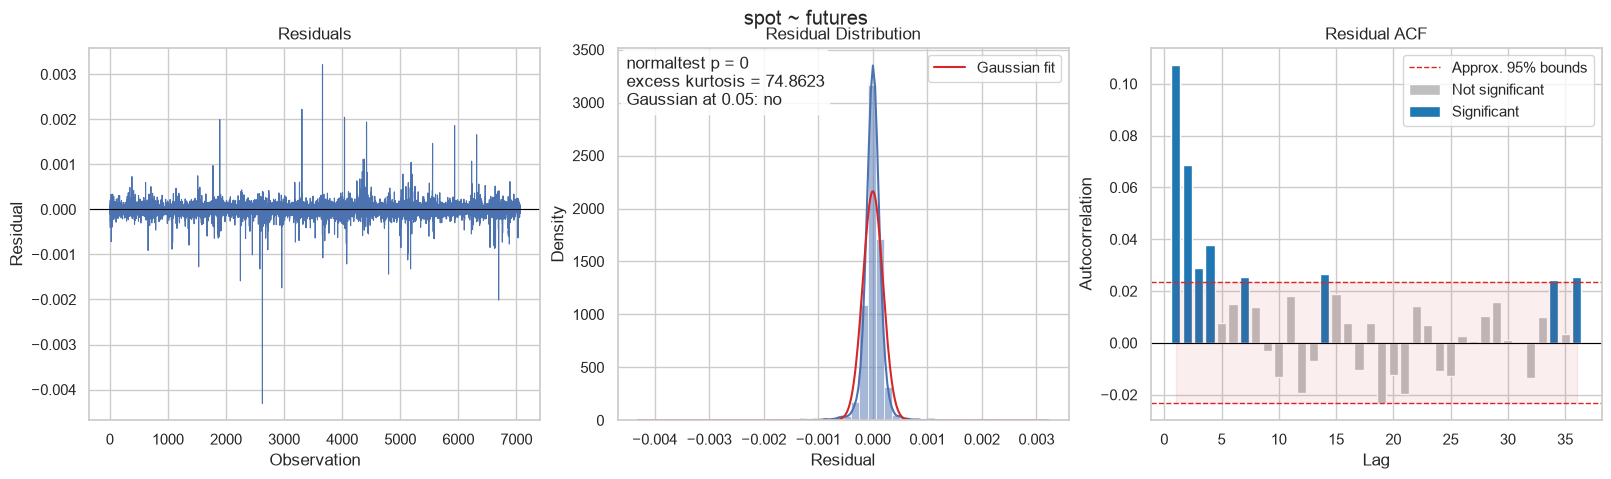

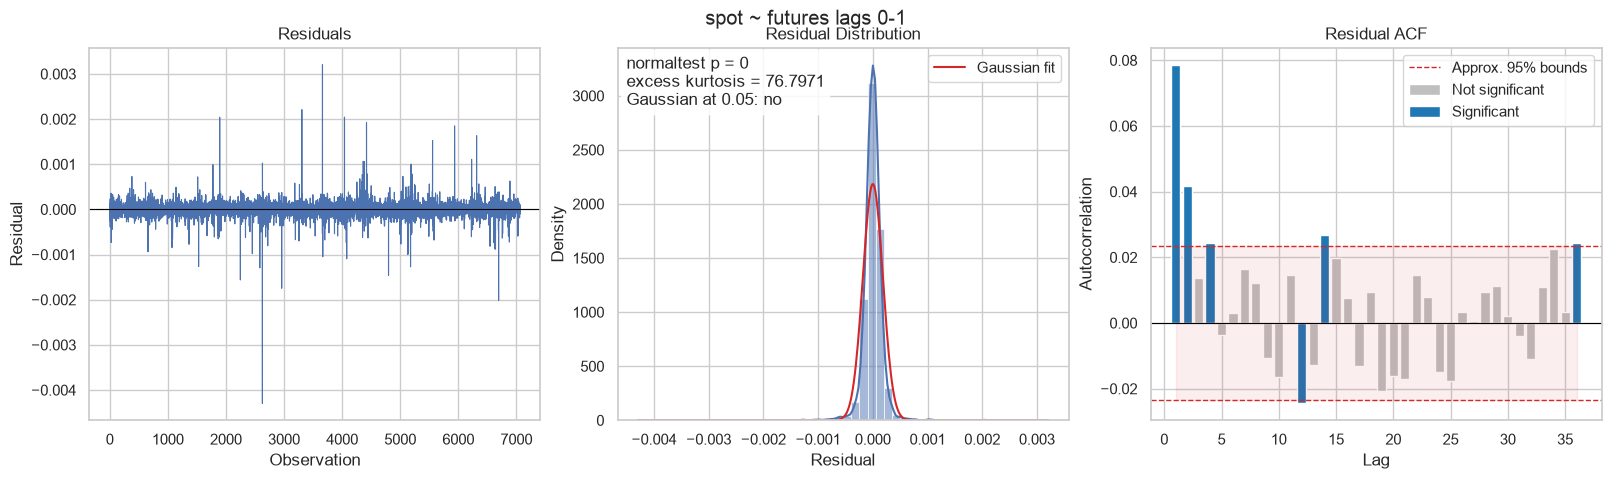

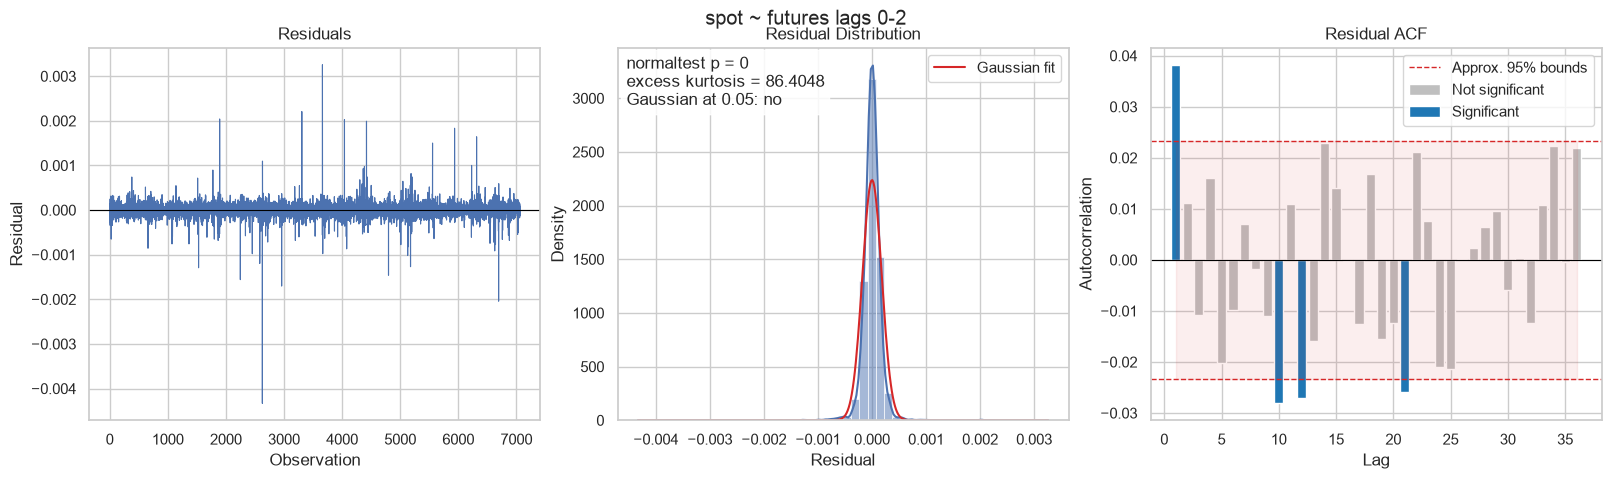

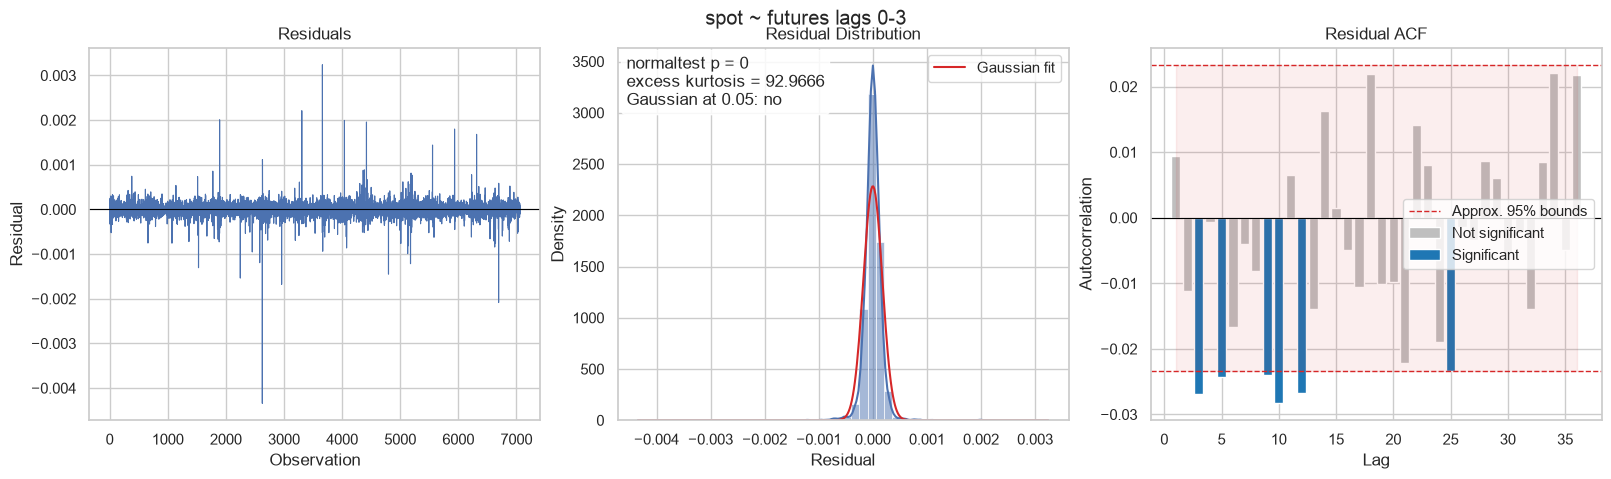

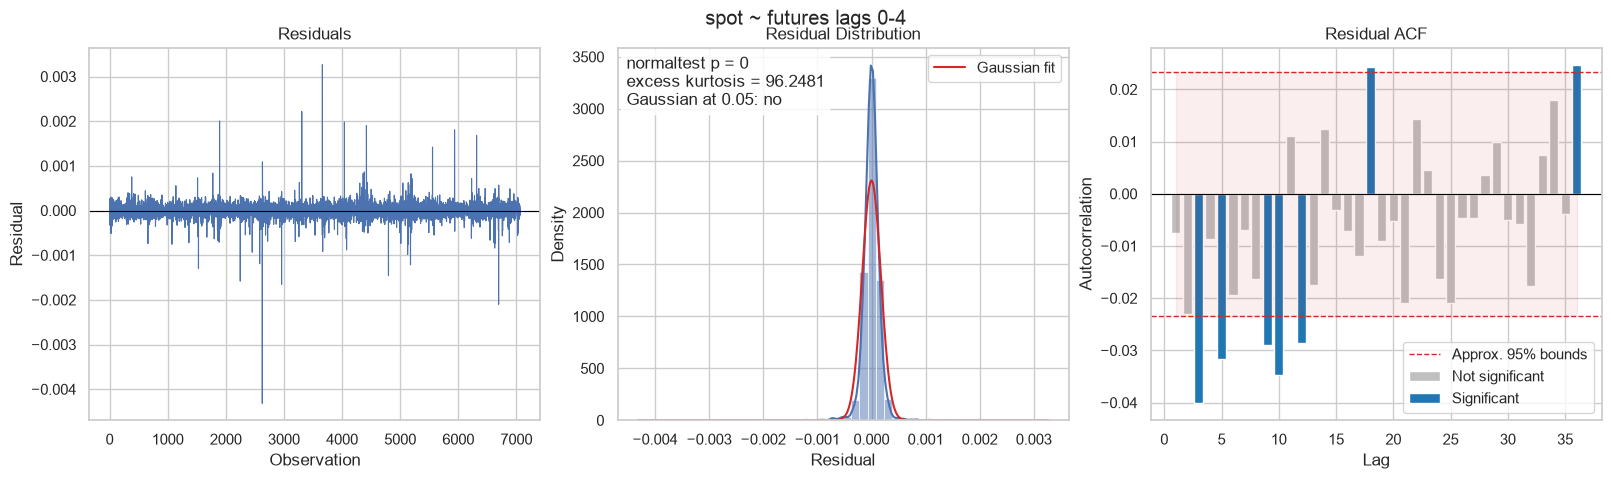

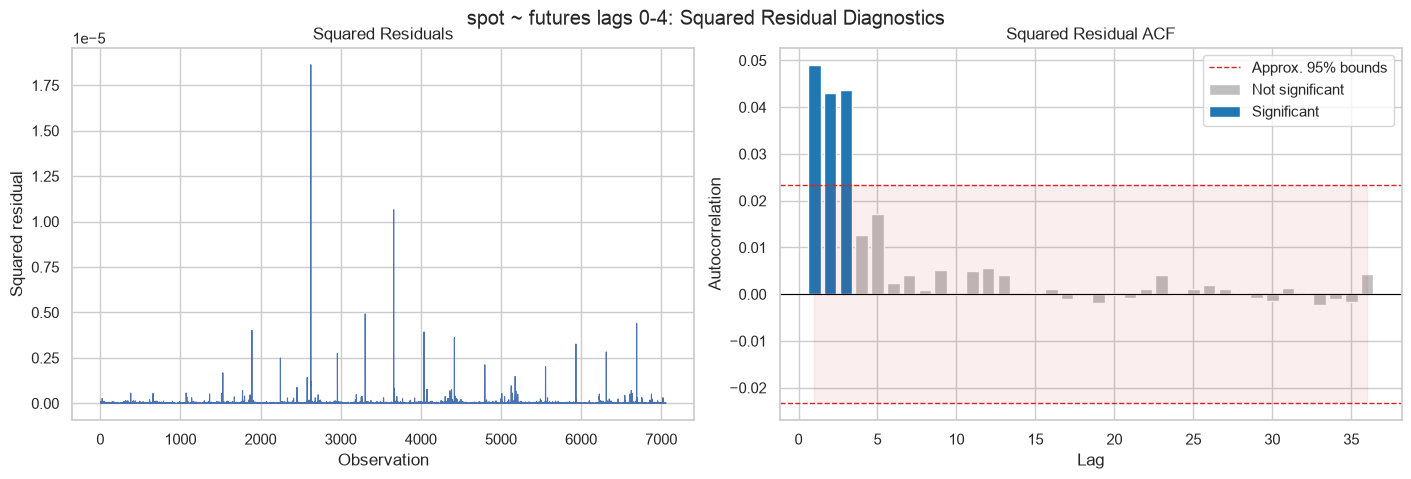

In [2]:
sns.set_theme(style="whitegrid")

for lag in range(MAX_FUTURES_LAG + 1):
    df[f"futures_rets_lag_{lag}"] = df["futures_rets"].shift(lag)


def fit_spot_on_futures_lags(max_lag: int) -> sm.regression.linear_model.RegressionResultsWrapper:
    model_df = df[
        ["spot_rets", *[f"futures_rets_lag_{lag}" for lag in range(max_lag + 1)]]
    ].dropna()
    y = model_df["spot_rets"]
    x = sm.add_constant(model_df.drop(columns="spot_rets"))
    return sm.OLS(y, x).fit()


def residual_acfs(residuals: pd.Series, max_lag: int) -> pd.Series:
    lags = range(1, max_lag + 1)
    return pd.Series(
        [residuals.autocorr(lag=lag) for lag in lags],
        index=pd.Index(lags, name="lag"),
        name="acf",
    )


def regression_metrics(
    name: str,
    max_lag: int,
    fit: sm.regression.linear_model.RegressionResultsWrapper,
) -> dict[str, float | int | str]:
    residuals = pd.Series(fit.resid, name="residuals")
    normal_test = stats.normaltest(residuals)
    return {
        "model": name,
        "max_futures_lag": max_lag,
        "n_observations": int(fit.nobs),
        "n_predictors": int(fit.df_model),
        "r_squared": fit.rsquared,
        "adj_r_squared": fit.rsquared_adj,
        "aic": fit.aic,
        "bic": fit.bic,
        "f_pvalue": fit.f_pvalue,
        "residual_mean": residuals.mean(),
        "residual_rmse": np.sqrt(np.mean(residuals**2)),
        "residual_mae": residuals.abs().mean(),
        "residual_normaltest_pvalue": normal_test.pvalue,
        "residual_excess_kurtosis": stats.kurtosis(residuals, fisher=True),
    }


def plot_residual_diagnostics(
    name: str,
    fit: sm.regression.linear_model.RegressionResultsWrapper,
) -> None:
    residuals = pd.Series(fit.resid, name="residuals")
    normal_test = stats.normaltest(residuals)
    excess_kurtosis = stats.kurtosis(residuals, fisher=True)
    residual_acf = residual_acfs(residuals, MAX_RESIDUAL_ACF_LAG)
    acf_significance_level = 1.96 / np.sqrt(len(residuals))

    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), constrained_layout=True)

    axes[0].plot(residuals.index, residuals.to_numpy(), linewidth=0.8)
    axes[0].axhline(0, color="black", linewidth=0.8)
    axes[0].set_title("Residuals")
    axes[0].set_xlabel("Observation")
    axes[0].set_ylabel("Residual")

    sns.histplot(residuals, bins=50, stat="density", kde=True, ax=axes[1])
    x = np.linspace(residuals.min(), residuals.max(), 400)
    normal_pdf = stats.norm.pdf(x, loc=residuals.mean(), scale=residuals.std(ddof=1))
    axes[1].plot(x, normal_pdf, color="tab:red", linewidth=1.5, label="Gaussian fit")
    axes[1].set_title("Residual Distribution")
    axes[1].set_xlabel("Residual")
    axes[1].legend()
    axes[1].text(
        0.02,
        0.98,
        "\n".join(
            [
                f"normaltest p = {normal_test.pvalue:.4g}",
                f"excess kurtosis = {excess_kurtosis:.4f}",
                f"Gaussian at {NORMALITY_ALPHA:g}: "
                f"{'yes' if normal_test.pvalue >= NORMALITY_ALPHA else 'no'}",
            ]
        ),
        transform=axes[1].transAxes,
        va="top",
        bbox={"boxstyle": "round", "facecolor": "white", "alpha": 0.85},
    )

    significant_acf = residual_acf.abs() > acf_significance_level
    axes[2].bar(
        residual_acf.index[~significant_acf],
        residual_acf.loc[~significant_acf],
        color="0.75",
        label="Not significant",
    )
    axes[2].bar(
        residual_acf.index[significant_acf],
        residual_acf.loc[significant_acf],
        color="tab:blue",
        label="Significant",
    )
    axes[2].axhline(0, color="black", linewidth=0.8)
    axes[2].axhline(
        acf_significance_level,
        color="tab:red",
        linestyle="--",
        linewidth=1,
        label="Approx. 95% bounds",
    )
    axes[2].axhline(
        -acf_significance_level,
        color="tab:red",
        linestyle="--",
        linewidth=1,
    )
    axes[2].fill_between(
        residual_acf.index,
        -acf_significance_level,
        acf_significance_level,
        color="tab:red",
        alpha=0.08,
    )
    axes[2].set_title("Residual ACF")
    axes[2].set_xlabel("Lag")
    axes[2].set_ylabel("Autocorrelation")
    axes[2].legend()

    fig.suptitle(name, y=1.03)


def plot_squared_residual_diagnostics(
    name: str,
    fit: sm.regression.linear_model.RegressionResultsWrapper,
) -> None:
    squared_residuals = pd.Series(fit.resid, name="squared_residuals") ** 2
    squared_residual_acf = residual_acfs(squared_residuals, MAX_RESIDUAL_ACF_LAG)
    acf_significance_level = 1.96 / np.sqrt(len(squared_residuals))
    significant_acf = squared_residual_acf.abs() > acf_significance_level

    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), constrained_layout=True)

    axes[0].plot(squared_residuals.index, squared_residuals.to_numpy(), linewidth=0.8)
    axes[0].set_title("Squared Residuals")
    axes[0].set_xlabel("Observation")
    axes[0].set_ylabel("Squared residual")

    axes[1].bar(
        squared_residual_acf.index[~significant_acf],
        squared_residual_acf.loc[~significant_acf],
        color="0.75",
        label="Not significant",
    )
    axes[1].bar(
        squared_residual_acf.index[significant_acf],
        squared_residual_acf.loc[significant_acf],
        color="tab:blue",
        label="Significant",
    )
    axes[1].axhline(0, color="black", linewidth=0.8)
    axes[1].axhline(
        acf_significance_level,
        color="tab:red",
        linestyle="--",
        linewidth=1,
        label="Approx. 95% bounds",
    )
    axes[1].axhline(
        -acf_significance_level,
        color="tab:red",
        linestyle="--",
        linewidth=1,
    )
    axes[1].fill_between(
        squared_residual_acf.index,
        -acf_significance_level,
        acf_significance_level,
        color="tab:red",
        alpha=0.08,
    )
    axes[1].set_title("Squared Residual ACF")
    axes[1].set_xlabel("Lag")
    axes[1].set_ylabel("Autocorrelation")
    axes[1].legend()

    fig.suptitle(f"{name}: Squared Residual Diagnostics", y=1.03)


model_specs = [
    ("spot ~ futures", 0),
    *[
        (f"spot ~ futures lags 0-{max_lag}", max_lag)
        for max_lag in range(1, MAX_FUTURES_LAG + 1)
    ],
]
fits = {
    name: fit_spot_on_futures_lags(max_lag)
    for name, max_lag in model_specs
}

metrics = pd.DataFrame(
    [
        regression_metrics(name, max_lag, fit)
        for name, max_lag in model_specs
        for fit in [fits[name]]
    ]
).set_index("model")

residual_acf_table = pd.DataFrame(
    {
        name: residual_acfs(pd.Series(fit.resid, name="residuals"), MAX_RESIDUAL_ACF_LAG)
        for name, fit in fits.items()
    }
)

print("\nLinear regression metrics")
with pd.option_context("display.max_columns", None, "display.width", 160):
    print(metrics.round(6))
print("\nFutures returns basic stats")
print(df["futures_rets"].describe())
print("\nSpot returns basic stats")
print(df["spot_rets"].describe())

# print("\nLinear regression coefficients")
# for name, fit in fits.items():
#     print(f"\n{name}")
#     print(fit.params.round(8))

# print("\nResidual ACFs")
# with pd.option_context("display.max_columns", None, "display.width", 160):
#     print(residual_acf_table.round(4))

for name, fit in fits.items():
    plot_residual_diagnostics(name, fit)

plot_squared_residual_diagnostics("spot ~ futures lags 0-4", fits["spot ~ futures lags 0-4"])

plt.show()

more work can be done in modelling the vol/shocks (as seen in the squared residuals ACF)

for lag 0, we could've treated the residuals as a time series, but making use of the data exploration, we could tell that regressing with lags 0-4 would be good, and looking at the ACF, it doesn't seem like much more can be done meaningfully.

Also the excess kurtosis being crazy high shouldn't really worry us, it's only a metric used to compare our models.

Also note the avg residual rmse is about the same as the std of the spot, hence the prediction this model gives is quite poor (as reflected by the r^2 value)

